In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

In [5]:
#1. generate synthetic classification dataset

X,y = make_blobs(n_samples=500, centers=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)



In [6]:
# 2.instantiate the RF model

# n_estimators i number of trees in the forest.
# max_depth controls the depth of individual tree.

model = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=42)

# 3. Fit model

model.fit(X_train, y_train)



RandomForestClassifier(max_depth=5, random_state=42)

In [7]:
# make predictions

y_pred = model.predict(X_test)

In [8]:
# Evaluate model

accuracy = accuracy_score(y_test, y_pred)
print(f"Scikit-learn Random Forest Model Accuracy: {accuracy * 100:.2f}%")


Scikit-learn Random Forest Model Accuracy: 100.00%


#### Feature Importance


Feature Importances: [0.49 0.51]


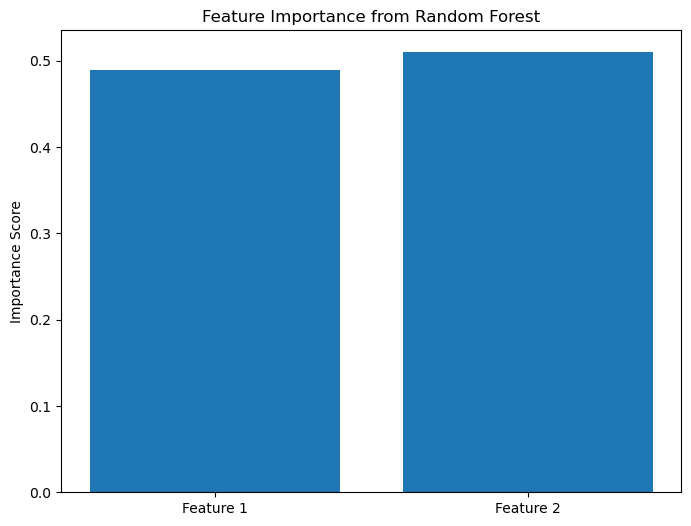

In [9]:
# Random Forests provide a very useful feature_importances_ attribute
# that shows which features were most influential in the model's predictions.
feature_importances = model.feature_importances_
print(f"\nFeature Importances: {feature_importances}")
# Let's visualize this
feature_names = ['Feature 1', 'Feature 2']
plt.figure(figsize=(8, 6))
plt.bar(feature_names, feature_importances)
plt.title("Feature Importance from Random Forest")
plt.ylabel("Importance Score")
plt.show()


## Evalution of Random Forest

#### Evaluation metrics

Since Random Forests can be used for both classification and regression, the evaluation metrics depend on the task:

For Classification: The same metrics we discussed for Decision Trees apply. You would use Accuracy, Precision, Recall, F1-Score, and ROC AUC to measure performance. Because Random Forests are an ensemble, they often produce a more stable and higher ROC AUC score than a single Decision Tree.

For Regression: The metrics are identical to those for Linear Regression. You would use Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R2 Score to assess the model's predictive power.


Unlike a single Decision Tree, Random Forests are less prone to overfitting, so pruning isn't as critical. The primary way to improve a Random Forest is by tuning its hyperparameters. The most important ones to know are:

n_estimators: The number of trees in the forest. Generally, more trees lead to a more stable and accurate model, but with diminishing returns and increased computational cost. A good starting point is often 100.

max_depth: The maximum depth of each individual tree. Limiting this prevents each tree from overfitting its specific bootstrap sample.

max_features: The number of features to consider at each split. This is a key parameter for controlling the randomness. sqrt is a common choice for classification, while log2 is common for regression.

min_samples_split: The minimum number of data points a node must have before it can be split.

min_samples_leaf: The minimum number of data points a leaf node must contain.

You can use a Grid Search or Random Search to systematically find the best combination of these parameters.



### RF Hyper parameter tuning


In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


#define model

model = RandomForestClassifier(random_state=42)

# define a dictionary of parameters to search over

param_grid = {
    'n_estimators': [50,100, 200],
    'max_depth': [3,5,10],
    'max_features': ['sqrt', 'log2']
}

# init Grid Search CV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Accuracy: {grid_search.best_score_:.2f}")

Best Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 50}
Best Accuracy: 1.00
